# Affinity Propagation - Olivetti Faces

**Dataset** : Olivetti Faces (400 images 64x64, 40 personnes, 10 images/personne)  
**Objectif** : clustering non supervise avec Affinity Propagation, selection sur validation explicite, puis evaluation sur test (ARI, NMI, Silhouette).  

**Specificites AP sur ce dataset** :
- AP est couteux en memoire/temps ($O(n^2)$), donc reduction de dimension par PCA avant clustering.
- AP ne fournit pas de `predict` natif: pour validation/test, on assigne chaque point au centre de cluster le plus proche.
- Le parametre `preference` controle fortement le nombre de clusters; il est tune via quantiles des similarites train.

Dataset complet: 400 echantillons
Train: 280 | Validation: 60 | Test: 60
Nombre d'identites reelles: 40
Variance expliquee (PCA AP, 100 composantes): 0.947


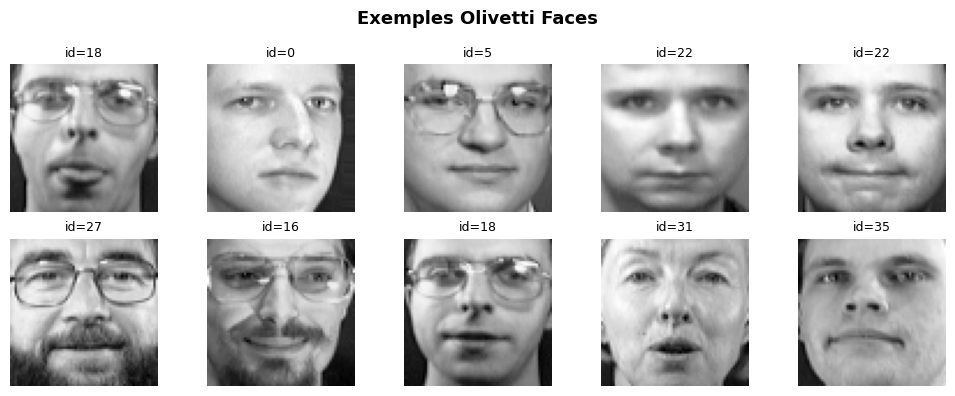

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Evite certains warnings loky sur la detection des coeurs physiques sous Windows
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import AffinityPropagation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Chargement des donnees
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data.astype(np.float64)     # (400, 4096)
images = faces.images                 # (400, 64, 64)
y_true = faces.target.astype(int)     # 40 identites

# Split train / validation / test (stratifie sur l'identite)
X_train, X_temp, y_train, y_temp, img_train, img_temp = train_test_split(
    X, y_true, images,
    test_size=0.30,
    stratify=y_true,
    random_state=42,
    shuffle=True,
 )
X_val, X_test, y_val, y_test, img_val, img_test = train_test_split(
    X_temp, y_temp, img_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
    shuffle=True,
 )

print(f"Dataset complet: {X.shape[0]} echantillons")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Nombre d'identites reelles: {len(np.unique(y_true))}")

# PCA pour reduire le cout de AP
pca_ap = PCA(n_components=100, whiten=True, random_state=42)
X_train_red = pca_ap.fit_transform(X_train)
X_val_red = pca_ap.transform(X_val)
X_test_red = pca_ap.transform(X_test)

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_red)
X_val_2d = pca_2d.transform(X_val_red)
X_test_2d = pca_2d.transform(X_test_red)

print(f"Variance expliquee (PCA AP, 100 composantes): {pca_ap.explained_variance_ratio_.sum():.3f}")

# Apercu du dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), np.random.choice(len(images), size=10, replace=False)):
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"id={y_true[idx]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Exemples Olivetti Faces", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Tuning AP sur la validation (plages completes)
def evaluate_clustering(X_eval, y_eval, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return {
            'n_clusters': len(unique_labels),
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False,
        }

    return {
        'n_clusters': len(unique_labels),
        'ari': adjusted_rand_score(y_eval, labels),
        'nmi': normalized_mutual_info_score(y_eval, labels),
        'silhouette': silhouette_score(X_eval, labels),
        'valid': True,
    }


def validation_score(metrics, target_clusters=40):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    n_clusters = metrics['n_clusters']
    if n_clusters < 5 or n_clusters > 90:
        return -1e8, False, 'cluster_count_out_of_range'

    # Penalite douce si loin des 40 identites reelles
    cluster_penalty = abs(n_clusters - target_clusters) / target_clusters

    silhouette_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = (
        0.40 * metrics['ari']
        + 0.35 * metrics['nmi']
        + 0.20 * silhouette_norm
        - 0.05 * cluster_penalty
    )
    return score, True, 'eligible'


# Preference calculee a partir des similarites train
similarities = -pairwise_distances(X_train_red, metric='sqeuclidean')

# Plages completes de tuning
preference_q_grid = np.linspace(0.01, 0.99, 25)
preference_grid = [float(np.quantile(similarities, q)) for q in preference_q_grid]
damping_grid = np.round(np.arange(0.50, 0.96, 0.05), 2).tolist()
convergence_iter_grid = [10, 20, 30]
max_iter_grid = [300, 500, 800]

results = []
trial = 0
total = (
    len(preference_grid)
    * len(damping_grid)
    * len(convergence_iter_grid)
    * len(max_iter_grid)
)

print(
    f"Nombre total d'essais AP: {total} "
    f"({len(preference_grid)} preferences x {len(damping_grid)} damping x "
    f"{len(convergence_iter_grid)} convergence_iter x {len(max_iter_grid)} max_iter)"
 )

for preference in preference_grid:
    for damping in damping_grid:
        for convergence_iter in convergence_iter_grid:
            for max_iter in max_iter_grid:
                trial += 1
                try:
                    ap = AffinityPropagation(
                        affinity='euclidean',
                        damping=damping,
                        preference=preference,
                        max_iter=max_iter,
                        convergence_iter=convergence_iter,
                        random_state=42,
                    )
                    labels_train = ap.fit_predict(X_train_red)

                    if ap.cluster_centers_ is None or len(ap.cluster_centers_) == 0:
                        raise ValueError('no_cluster_centers')

                    labels_val = pairwise_distances_argmin(X_val_red, ap.cluster_centers_)
                    metrics_val = evaluate_clustering(X_val_red, y_val, labels_val)
                    score_val, eligible_val, eligibility_reason = validation_score(metrics_val)

                except Exception as exc:
                    metrics_val = {
                        'n_clusters': np.nan,
                        'ari': np.nan,
                        'nmi': np.nan,
                        'silhouette': np.nan,
                        'valid': False,
                    }
                    score_val = -1e9
                    eligible_val = False
                    eligibility_reason = f"error: {type(exc).__name__}"

                result = {
                    'trial': trial,
                    'preference': preference,
                    'damping': damping,
                    'convergence_iter': convergence_iter,
                    'max_iter': max_iter,
                    'score_val': score_val,
                    'eligible_val': eligible_val,
                    'eligibility_reason': eligibility_reason,
                    'metrics_val': metrics_val,
                }
                results.append(result)

                status = 'eligible' if eligible_val else 'rejete'
                print(
                    f"Essai {trial}/{total} | score={score_val:.4f} | "
                    f"ARI={metrics_val['ari']:.4f} | NMI={metrics_val['nmi']:.4f} | "
                    f"SIL={metrics_val['silhouette']:.4f} | k={metrics_val['n_clusters']} | "
                    f"statut={status} | damping={damping:.2f} | "
                    f"conv_iter={convergence_iter} | max_iter={max_iter}"
                )

eligible_results = [r for r in results if r['eligible_val']]
if len(eligible_results) == 0:
    raise RuntimeError("Aucun modele eligible. Elargir la grille ou assouplir les filtres.")

best_result = max(eligible_results, key=lambda r: r['score_val'])
print("\nMeilleur modele (validation):")
print(best_result)

Nombre total d'essais AP: 2250 (25 preferences x 10 damping x 3 convergence_iter x 3 max_iter)
Essai 1/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=10 | max_iter=300
Essai 2/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=10 | max_iter=500
Essai 3/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=10 | max_iter=800
Essai 4/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=20 | max_iter=300
Essai 5/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=20 | max_iter=500
Essai 6/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=eligible | damping=0.50 | conv_iter=20 | max_iter=800
Essai 7/2250 | score=0.2598 | ARI=0.0326 | NMI=0.5526 | SIL=-0.0410 | k=6 | statut=

In [11]:
# Entrainement final sur TRAIN uniquement (modele choisi via validation), puis evaluation sur test
best_ap = AffinityPropagation(
    affinity='euclidean',
    damping=best_result['damping'],
    preference=best_result['preference'],
    max_iter=best_result['max_iter'],
    convergence_iter=best_result['convergence_iter'],
    random_state=42,
 )
labels_train = best_ap.fit_predict(X_train_red)

if best_ap.cluster_centers_ is None or len(best_ap.cluster_centers_) == 0:
    raise RuntimeError("Le modele final n'a genere aucun centre.")

# Evaluation test unique
labels_test = pairwise_distances_argmin(X_test_red, best_ap.cluster_centers_)

def safe_silhouette(X_eval, labels):
    return np.nan if len(np.unique(labels)) < 2 else silhouette_score(X_eval, labels)

metrics_test = {
    'n_clusters': int(len(np.unique(labels_test))),
    'ari': float(adjusted_rand_score(y_test, labels_test)),
    'nmi': float(normalized_mutual_info_score(y_test, labels_test)),
    'silhouette': float(safe_silhouette(X_test_red, labels_test)),
}

print("Protocole: hyperparametres selectionnes sur validation, puis apprentissage train seul")
print("Evaluation finale sur TEST (une seule fois)")
print(f"Clusters predits sur test: {metrics_test['n_clusters']}")
print(f"ARI : {metrics_test['ari']:.4f}")
print(f"NMI : {metrics_test['nmi']:.4f}")
print(f"Silhouette : {metrics_test['silhouette']:.4f}")

cluster_ids, cluster_sizes = np.unique(labels_test, return_counts=True)
print("\nTop 10 tailles de clusters (test):")
for cid, size in sorted(zip(cluster_ids, cluster_sizes), key=lambda x: -x[1])[:10]:
    print(f"Cluster {cid:>2}: {size:>2} echantillons")

Protocole: hyperparametres selectionnes sur validation, puis apprentissage train seul
Evaluation finale sur TEST (une seule fois)
Clusters predits sur test: 45
ARI : 0.3000
NMI : 0.9229
Silhouette : 0.0252

Top 10 tailles de clusters (test):
Cluster 29:  3 echantillons
Cluster 43:  3 echantillons
Cluster 60:  3 echantillons
Cluster 100:  3 echantillons
Cluster 17:  2 echantillons
Cluster 64:  2 echantillons
Cluster 70:  2 echantillons
Cluster 73:  2 echantillons
Cluster 124:  2 echantillons
Cluster 128:  2 echantillons


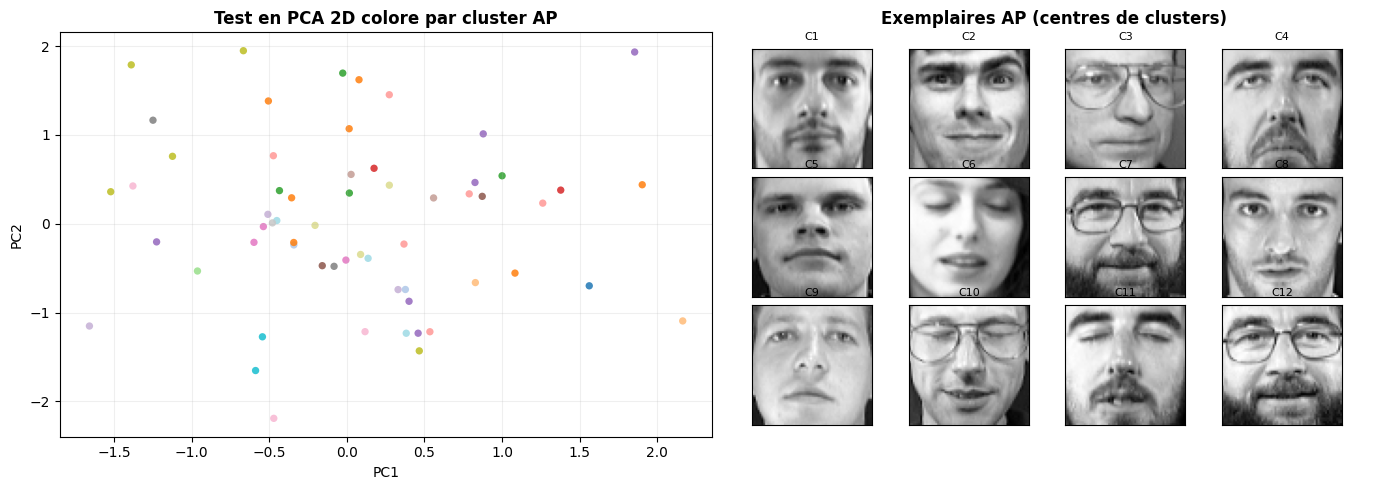

In [12]:
# Visualisations: projection 2D test + visages exemplaires
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Projection des clusters predits sur test
scatter = axes[0].scatter(
    X_test_2d[:, 0],
    X_test_2d[:, 1],
    c=labels_test,
    cmap='tab20',
    s=28,
    alpha=0.85,
    linewidths=0,
 )
axes[0].set_title("Test en PCA 2D colore par cluster AP", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.2)

# Affichage d'exemplaires (centres AP appris sur train)
exemplar_indices = best_ap.cluster_centers_indices_
max_show = min(12, len(exemplar_indices))
selected = exemplar_indices[:max_show]

axes[1].axis('off')
axes[1].set_title("Exemplaires AP (centres de clusters)", fontsize=12, fontweight='bold')

# Inset axes pour afficher plusieurs visages dans le panneau de droite
n_cols = 4
n_rows = int(np.ceil(max_show / n_cols))
for i, ex_idx in enumerate(selected):
    row = i // n_cols
    col = i % n_cols
    x0 = 0.02 + col * 0.24
    y0 = 0.98 - (row + 1) * (0.95 / max(1, n_rows))
    w = 0.22
    h = 0.95 / max(1, n_rows) - 0.02
    ax_in = axes[1].inset_axes([x0, y0, w, h])
    ax_in.imshow(img_train[ex_idx], cmap='gray')
    ax_in.set_xticks([])
    ax_in.set_yticks([])
    ax_in.set_title(f"C{i+1}", fontsize=8)

plt.tight_layout()
plt.show()